## **ДИСКУРС-АНАЛИЗ СОЛИДАРНОСТИ В СМИ О БРИКС И ГЮ**

In [1]:
import os
import re
from pathlib import Path
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import re

try:
    import nltk
except Exception:
    nltk = None

import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer

from scipy import stats
from scipy.stats import spearmanr, kendalltau

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 250)

## Загрузка корпуса

In [3]:
GS = "gs_polit_translated.csv"

# Читаем исходную таблицу
df1 = pd.read_csv(GS)

In [54]:
#оставляем только нужные колонки
required_columns = [
    "link",
    "title",
    "text",
    "date",
    "translated_text",
    "is_processed",
    "paragraphs_translated",
]

df1 = df1[required_columns].copy()

In [4]:
# Берём перевод, а если его нет — исходный текст
translated = df1["translated_text"].fillna("").astype(str).str.strip()
original = df1["text"].fillna("").astype(str).str.strip()

use_translation = translated.ne("") & ~translated.str.lower().isin(["nan", "none"])
text = np.where(use_translation, translated, original)

#год берём только из колонки date
year = df1["date"].fillna("").astype(str).str.extract(r"(20\d{2})")[0]

# Собираем рабочий датафрейм.
df = pd.DataFrame({
    "year": pd.to_numeric(year, errors="coerce"),
    "title": df1["title"].fillna("").astype(str).str.strip(),
    "text": pd.Series(text).fillna("").astype(str).str.strip(),
    "url": df1["link"].fillna("").astype(str).str.strip(),
    "text_source": np.where(use_translation, "translated", "original"),
})

df["source_domain"] = df["url"].str.extract(r"https?://([^/]+)")[0].fillna("").str.lower()

#убираем пустые тексты и полные дубли
before = len(df)
df = df[df["text"] != ""].copy()
df = df.drop_duplicates(subset=["url", "title", "text"], keep="first").copy()

print("Количество строк до очистки:", before)
print("Количество строк после очистки:", df.shape)
print("Перевод текста:", int((df["text_source"] == "translated").sum()))
print("Ориг тексты", int((df["text_source"] == "original").sum()))
print("Строк с годом, которые были распознаны", int(df["year"].notna().sum()))

print("Распределение по годам:")
print(df["year"].dropna().astype(int).value_counts().sort_index())

Количество строк до очистки: 25310
Количество строк после очистки: (12171, 6)
Перевод текста: 8214
Ориг тексты 3957
Строк с годом, которые были распознаны 8866
Распределение по годам:
year
2009      35
2010      40
2011      94
2012      55
2013     113
2014      44
2015      50
2016     101
2017     579
2018     234
2019     155
2020     110
2021     151
2022     287
2023     842
2024    2352
2025    3624
Name: count, dtype: int64


In [5]:
df

,year,title,text,url,text_source,source_domain
0,2019.0,"BRICS summit: China warns against ‘protectionism, bullying’","Chinese President Xi Jinping says mounting protectionism has eroded international trade and investment, in what was most probably a reference to US President Donald Trump’s ongoing trade war with China. He made the comments as leaders from the fi...",https://www.aljazeera.com/video/2019/11/15/brics-summit-china-warns-against-protectionism-bullying,translated,www.aljazeera.com
1,2024.0,"Angered over BRICS veto, Venezuela recalls ambassador to Brazil","Venezuela’s Foreign Ministry has accused Brazilian officials of making ‘interventionist, rude statements’. Share Save Venezuela has pulled its ambassador from Brazil in a spat over Caracas’s failed recent bid to join the BRICS alliance of major d...",https://www.aljazeera.com/news/2024/10/30/angered-over-brics-veto-venezuela-recalls-ambassador-to-brazil,translated,www.aljazeera.com
2,2014.0,The BRICS bank: Multipolarity or Beijing Consensus?,"The BRICS’ initiatives for a democratic global order should be welcomed, but the group is still dominated by China. By Richard Javad Heydarian Richard Javad Heydarian is a specialist in Asian geopolitical and economic affairs. Share Save No longe...",https://www.aljazeera.com/opinions/2014/7/21/the-brics-bank-multipolarity-or-beijing-consensus,translated,www.aljazeera.com
3,2023.0,‘Hegemonism not in China’s DNA’: Xi calls for BRICS expansion,Xi says China seeks a more just and equitable international order and rejects ‘bloc confrontation’. Share Save Chinese President Xi Jinping has called for an expansion of the BRICS grouping of emerging economies to build a more just and equitable...,https://www.aljazeera.com/economy/2023/8/23/hegemonism-not-in-chinas-dna-xi-calls-for-brics-expansion,translated,www.aljazeera.com
4,2014.0,BRICS bank rattles the ‘Washington Consensus’,"Five emerging economies set up $100bn development bank, seen as direct competition to World Bank and IMF. By Gabriel Elizondo Share Save FORTALEZA, Brazil – In a sprawling events hall in this sun-soaked, laid-back northeastern city, the leaders o...",https://www.aljazeera.com/features/2014/7/31/brics-bank-rattles-the-washington-consensus,translated,www.aljazeera.com
...,...,...,...,...,...,...
25305,2025.0,China ready to advance greater BRICS cooperation: spokesperson,"BEIJING, Jan. 7 (Xinhua) -- China stands ready to work with all BRICS countries to embrace the spirit of openness, inclusiveness and win-win cooperation, and advance the high-quality development of greater BRICS cooperation, Chinese foreign minis...",https://english.news.cn/20250107/f528b0b5dbd54d7fa296322de5a68791/c.html,original,english.news.cn
25306,2025.0,"Indonesia strengthens global role through BRICS membership, foreign ministry says","JAKARTA, Jan. 7 (Xinhua) -- Indonesia welcomes Brazil's announcement as chair of BRICS 2025, which recognizes the Southeast Asian country as a full member, the Indonesian Ministry of Foreign Affairs said on Tuesday.\r\n""This milestone reflects In...",https://english.news.cn/20250107/ba5e4b6c6ce041cd8071a40003865924/c.html,original,english.news.cn
25307,2025.0,"Indonesia strengthens global role through BRICS membership, foreign ministry says","JAKARTA, Jan. 7 (Xinhua) -- Indonesia welcomes Brazil's announcement as chair of BRICS 2025, which recognizes the Southeast Asian country as a full member, the Indonesian Ministry of Foreign Affairs said on Tuesday.\r\n""This milestone reflects In...",https://english.news.cn/20250107/ae774835c652435daa2f601017cf5dce/c.html,original,english.news.cn
25308,2025.0,"Indonesia strengthens global role through BRICS membership, foreign ministry says","JAKARTA, Jan. 7 (Xinhua) -- Indonesia welcomes Brazil's announcement as chair of BRICS 2025, which recognizes the Southeast Asian country as a full member, the Indonesian Ministry of Foreign Affairs said on Tuesday.\r\n""This milestone reflects In...",https://english.news.cn/asi

## Очистка корпуса - убираем шумы, включая лишние пробелы, пустые места --> делаем датафрейм пригодный для анализа текстов

In [6]:
clean = {
    "min_text_len": 120,
    "min_df": 3,
    "ngram_range": (2, 3),
    "analysis_exclude_terms": [
        "brics", "country", "conference", "summit", "meeting",
        "leader", "member", "state", "states", "group", "international", "include",
        "united", "nations", "general", "assembly", "secretary", "chairman",
        "video", "news", "report", "reported", "inside", "story", "share", "save",
        "said", "say", "says", "article", "source", "agency", "editor", "photo",
        "minister", "prime", "president", "official", "according", "told", "added",
        "unit", "nation", "meet", "year", "new"
    ],
#удаляем шумы 
    "artifact_terms": [
        "nthe", "nmr", "nthat", "nand", "nfor", "nfrom", "nwith", "nthis",
        "nbsp", "amp", "quot", "http", "https", "www", "com",
        "reuters", "afp", "apnews", "prensa", "latina", "xinhua", "sputnik",
        "aljazeera", "bloomberg", "copyright", "subscribe", "advertisement",
        "que", "los", "las", "del", "para", "por", "con", "una", "uno", "como", "sobre"
    ],
    "window": 5,
    "graph_min_weight": 2,
    "graph_top_labels": 15,
    "index_weights": {
        "norms_freq_z": 0.25,
        "cooperation_freq_z": 0.25,
        "reform_freq_z": 0.25,
        "development_freq_z": 0.25,
    },
    "seed": 42,
}

In [7]:
def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\\n", " ").replace("\\t", " ").replace("\\r", " ")
    text = text.replace("/n", " ").replace("&nbsp;", " ").replace("&amp;", " and ")
    text = text.replace("\xa0", " ")
    text = text.replace("\u2009", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def title_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", str(text).lower())[:5000]


def text_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", str(text).lower())[:10000]


before = len(df)
df["text_clean"] = df["text"].apply(basic_clean)
df["title_clean"] = df["title"].apply(basic_clean)

df = df[df["text_clean"].str.len() > clean["min_text_len"]].copy()
after = len(df)

df["title_fp"] = df["title_clean"].apply(title_fingerprint)
df["text_fp"] = df["text_clean"].apply(text_fingerprint)

#удаляем почти точные дубли по заголовку+тексту (в СМИ такое часто может быть)
df = df.drop_duplicates(subset=["title_fp", "text_fp"], keep="first").copy()
after = len(df)

print(
    f"Удалено при очистке: {before - after} записей "
    f"(короче {clean['min_text_len']} символов: {before - after})"
)
print("Размер корпуса после очистки", df.shape)
print(df[["year", "title_clean"]].head())

Удалено при очистке: 336 записей (короче 120 символов: 336)
Размер корпуса после очистки (11835, 10)
     year                                                      title_clean
0  2019.0      BRICS summit: China warns against ‘protectionism, bullying’
1  2024.0  Angered over BRICS veto, Venezuela recalls ambassador to Brazil
2  2014.0              The BRICS bank: Multipolarity or Beijing Consensus?
3  2023.0    ‘Hegemonism not in China’s DNA’: Xi calls for BRICS expansion
4  2014.0                    BRICS bank rattles the ‘Washington Consensus’


## Нормализация текста для подсчета устойчивых единиц текста, а не отдельных слов

In [9]:
artifact_terms = set(clean.get("artifact_terms", []))

def simple_lemma(token: str) -> str:
    token = token.lower()

    irregular = {
        "brics": "brics",
        "countries": "country",
        "responsibilities": "responsibility",
        "partnerships": "partnership",
        "mechanisms": "mechanism",
        "reforms": "reform",
        "measures": "measure",
        "actions": "action",
        "rights": "right",
        "investments": "investment",
        "flows": "flow",
        "goals": "goal",
    }
    if token in irregular:
        return irregular[token]

    if token.endswith("ies") and len(token) > 4:
        return token[:-3] + "y"
    if token.endswith("ing") and len(token) > 5:
        return token[:-3]
    if token.endswith("ed") and len(token) > 4:
        return token[:-2]
    if token.endswith("s") and len(token) > 4 and not token.endswith("ss"):
        return token[:-1]

    return token


def normalize_to_lemmas(text: str) -> list[str]:
    tokens = []
    for token in re.findall(r"[A-Za-z]+", str(text).lower()):
        lemma = simple_lemma(token)
        if not re.fullmatch(r"[a-z]{3,}", lemma):
            continue
        if lemma in artifact_terms:
            continue
        tokens.append(lemma)
    return tokens


df["lemmas"] = df["text_clean"].apply(normalize_to_lemmas)
df["lemma_text"] = df["lemmas"].apply(" ".join)

print(df[["year", "lemma_text"]].head())

     year  \
0  2019.0   
1  2024.0   
2  2014.0   
3  2023.0   
4  2014.0   

                                                                                                                                                                                                                                                  lemma_text  
0  chinese president jinp says mount protectionism has erod international trade and investment what was most probably reference president donald trump ongo trade war with china made the comment leader from the five major emerg economy met for the se...  
1  venezuela foreign ministry has accus brazilian official mak interventionist rude statement share save venezuela has pull its ambassador from brazil spat over caraca fail recent bid join the brics alliance major develop nation venezuela foreign mi...  
2  the brics initiative for democratic global order should welcom but the group still dominat china richard javad heydarian richard javad heydarian speciali

In [10]:
df["token_count"] = df["lemmas"].str.len()
print(df[["token_count"]].describe())

        token_count
count  11835.000000
mean     414.444867
std      491.576829
min        0.000000
25%      164.000000
50%      286.000000
75%      549.000000
max    16278.000000


##  Прежде чем считать индексы солидарности, полезно просто посмотреть, о чем вообще чаще всего говорится в корпусе

In [11]:
#убираем стоп-слова
stop_words = set(ENGLISH_STOP_WORDS)
analysis_exclude_terms = set(clean.get("analysis_exclude_terms", []))
artifact_terms = set(clean.get("artifact_terms", []))
analysis_exclude_terms.update({"international", "state", "states", "global"})
analysis_exclude_terms.update(artifact_terms)

In [12]:
#частотность отдельных лемм 
word_vectorizer = CountVectorizer(
    min_df=clean["min_df"],
    stop_words=list(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

word_matrix = word_vectorizer.fit_transform(df["lemma_text"])
word_list = word_vectorizer.get_feature_names_out()
word_counts = word_matrix.sum(axis=0).A1

df_word_freq = pd.DataFrame({
    "term": word_list,
    "freq": word_counts,
})

df_word_freq = df_word_freq.sort_values("freq", ascending=False).reset_index(drop=True)

In [13]:
#дополнительная фильтрация слов
df_word_freq = df_word_freq[
    (~df_word_freq["term"].isin(stop_words))
    & (~df_word_freq["term"].isin(analysis_exclude_terms))
    & (df_word_freq["term"].str.len() > 2)
].reset_index(drop=True)

In [15]:
#частоты 2–3-грамм
vectorizer_ng = CountVectorizer(
    ngram_range=clean["ngram_range"],
    min_df=clean["min_df"],
    stop_words=sorted(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

X_ng = vectorizer_ng.fit_transform(df["lemma_text"])
terms_ng = vectorizer_ng.get_feature_names_out()
freq_ng = X_ng.sum(axis=0).A1

df_freq_exp = (pd.DataFrame({"exp": terms_ng, "freq": freq_ng}).sort_values("freq", ascending=False).reset_index(drop=True))

In [16]:
#убираем n-граммы, где есть стоп-слова
def has_bad_token(phrase: str) -> bool:
    for token in phrase.split():
        if token in stop_words or token in analysis_exclude_terms:
            return True
    return False

df_freq_exp  = df_freq_exp[~df_freq_exp["exp"].apply(has_bad_token)].reset_index(drop=True)

In [17]:
print("Леммы")
print(df_word_freq.head(100))

print("Частотность выражений")
print(df_freq_exp.head(100))

Леммы
           term   freq
0         china  27201
1         south  18813
2        russia  18652
3   cooperation  18494
4         india  18179
..          ...    ...
95     business   3453
96          ses   3450
97       expand   3431
98          bas   3417
99         high   3397

[100 rows x 2 columns]
Частотность выражений
                     exp  freq
0           south africa  9776
1            india china  4482
2           russia india  3701
3          brazil russia  3316
4     russia india china  3117
..                   ...   ...
95         food security   492
96      business council   492
97        covid pandemic   486
98  belt road initiative   485
99          brasil rusia   484

[100 rows x 2 columns]


In [18]:
#сохраняем частотности лемм
df_word_freq.to_csv("lemms_frequency.csv", index=False)

In [20]:
#сохраняем частотности выражений
df_freq_exp.to_csv("expression_frequency.csv", index=False)

## Что дает частотный этап

На этом шаге я смотрю, какой словарь реально доминирует в корпусе. Это предварительная проверка, что выбранные измерения не оторваны от текста.

Если в топе устойчиво держатся слова кооперации, развития и многосторонности, значит солидарность в декларациях выражается системно, а не случайно. Этот блок служит входом к последующим метрикам, но не заменяет их.

In [21]:
#Словари
norms_solidarity = {
    'solidarity', 'justice', 'equity', 'fairness', 'equality',
    'inclusive', 'inclusiveness', 'inclusion',
    'rights', 'human rights', 'fundamental rights', 'social rights',
    'dignity', 'human dignity',
    'responsibility', 'responsibilities', 'shared', 'common',
    'collective', 'mutual', 'respect', 'mutual respect',
    'rule of law', 'international law', 'international rule of law',
    'sovereign equality', 'sovereign rights',
    'common but differentiated responsibilities',
    'multipolar', 'multilateralism', 'multilateral',
    'inclusive growth', 'shared prosperity', 'shared responsibility',
    'mutual benefit', 'mutually beneficial', 'win win',
    'non discrimination', 'non-discrimination',
    'fair representation', 'equitable representation',
    'global justice', 'social justice',
    'peaceful coexistence', 'peaceful co-existence',
    'mutual understanding', 'mutual trust',
    'predictability', 'stability', 'balanced',
}

cooperation_solidarity = {
    'cooperation', 'cooperate', 'cooperative',
    'coordination', 'coordinate', 'joint',
    'partnership', 'partnerships', 'strategic partnership',
    'mechanism', 'mechanisms', 'framework', 'working group',
    'task force', 'contact group',
    'common position', 'common stand',
    'collective action', 'pool resources',
    'institutional collaboration', 'institutional cooperation',
    'consensus', 'exchange', 'exchange of views',
    'capacity building', 'joint capacity building',
    'brics cooperation', 'south south cooperation', 'global south cooperation',
    'cooperation among', 'cooperation between',
    'joint statement', 'joint declaration', 'joint communique',
    'joint initiative', 'joint programme', 'joint program',
    'joint project', 'joint work', 'joint efforts',
    'coordinated measures', 'coordinated action',
    'information sharing', 'experience sharing',
    'peer learning', 'best practices',
    'intergovernmental cooperation',
    'people to people exchanges', 'people-to-people exchanges',
    'dialogue', 'political dialogue', 'regular dialogue',
}

reform_solidarity = {
    'unilateral', 'unilateral measures', 'unilateral actions',
    'sanctions', 'coercive', 'coercion',
    'hegemonic', 'hegemony',
    'domination', 'dominance',
    'neo colonial', 'neocolonial', 'neo-colonial',
    'reform', 'reforms', 'reforming',
    'global governance', 'reform of global governance',
    'security council reform', 'reform of the security council',
    'reform of the united nations', 'un reform',
    'multilateral trading system',
    'underrepresentation', 'under-representation',
    'non interference', 'non-interference',
    'non intervention', 'non-intervention',
    'unjust', 'unfair', 'imbalanced', 'asymmetric',
    'double standards',
    'outdated structures', 'outdated institutions',
    'institutional reform', 'systemic reform',
    'democratisation of international relations',
    'democratization of international relations',
    'inclusive multilateralism',
    'greater voice', 'greater representation',
}

development_solidarity = {
    'development', 'sustainable development', 'sustainable growth',
    'infrastructure', 'infrastructure development',
    'finance', 'financing', 'development finance',
    'development bank', 'new development bank', 'ndb',
    'investment', 'investments', 'investment flows',
    'economic growth', 'inclusive growth',
    'technology transfer', 'transfer of technology',
    'capacity building', 'institutional capacity',
    'industrialisation', 'industrialization',
    'poverty', 'poverty eradication', 'poverty reduction',
    'food security', 'energy security',
    'health', 'public health', 'global health',
    'education', 'access to education',
    'climate finance', 'climate-resilient development',
    'digital', 'digitalisation', 'digitalization', 'digital economy',
    'connectivity', 'digital connectivity',
    'sdgs', 'sustainable development goals',
    'developing countries', 'global south',
    'social development', 'human development',
    'inclusive development', 'balanced development',
    'green development', 'low carbon development',
    'economic diversification', 'structural transformation',
}

# Базовый словарь (без медиа-надстройки)
base_terms = {
    'norms': norms_solidarity,
    'cooperation': cooperation_solidarity,
    'reform': reform_solidarity,
    'development': development_solidarity,
}

# Словарь приводится тем же способом, что и корпус.
# Это важно для совпадения форм вроде reforms/reform, partnerships/partnership.
dictionary = {
    dim: {tuple(normalize_to_lemmas(term)) for term in base_terms[dim] if normalize_to_lemmas(term)}
    for dim in base_terms
}

In [22]:
#подсчет вхождений словаря
def count_lexicon_items(lemmas, lexicon_items):
    total_count = 0
    ngram_cache = {}

    for item in lexicon_items:
        n = len(item)

#одиночные леммы
        if n == 1:
            total_count += lemmas.count(item[0])
            continue

#n-граммы - один раз!!! строим все окна нужной длины
        if n not in ngram_cache:
            if len(lemmas) < n:
                ngram_cache[n] = []
            else:
                ngram_cache[n] = [
                    tuple(lemmas[i : i + n])
                    for i in range(len(lemmas) - n + 1)
                ]

        total_count += sum(1 for gram in ngram_cache[n] if gram == item)

    return total_count

In [23]:
#считаем абсолютные и относительные частоты по базовому словарю
def compute_lexicon_indices_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    token_count = len(lemmas) if len(lemmas) > 0 else 1

    raw_counts = {}
    rel_freqs = {}

    for dim_name, lexicon_items in dictionary.items():
        raw_value = count_lexicon_items(lemmas, lexicon_items)
        raw_counts[f"{dim_name}_raw"] = raw_value
        rel_freqs[f"{dim_name}_freq"] = raw_value / token_count

    return pd.Series({**raw_counts, **rel_freqs, "tokens": token_count})


lex_df = df.apply(compute_lexicon_indices_row, axis=1)
df = pd.concat([df, lex_df], axis=1)

print("Добавлены базовые колонки частот")
print([c for c in df.columns if c.endswith("_freq")][:20])

Добавлены базовые колонки частот
['norms_freq', 'cooperation_freq', 'reform_freq', 'development_freq']


## Как устроены метрики по измерениям
Для каждого документа формируем систему метрик по четырём  измерениям: нормативная солидарность, кооперативная солидарность, солидарность в развитии, реформаторская солид
На каждом измерении рассчитываются три показателя: 
raw фиксирует абсолютное число словарных совпадений в тексте
freq отражает относительную частоту этих совпадений с учётом длины документа
freq_z представляет собой z-нормированное значение, показывающее положение документа относительно распределения по всему корпусу

In [24]:
#применение к df и стандартизация
freq_cols = ["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]

for col in freq_cols:
    if col not in df.columns:
        raise KeyError(f"Ожидаемая колонка '{col}' отсутствует в df")

    series = df[col]
    mean_value = float(series.mean())
    std_value = float(series.std(ddof=0))

    if std_value == 0 or np.isnan(std_value):
        std_value = 1.0

    df[col + "_z"] = (series - mean_value) / std_value

In [25]:
print(lex_df.head())

   norms_raw  cooperation_raw  reform_raw  development_raw  norms_freq  \
0        0.0              0.0         0.0              1.0    0.000000   
1        2.0              0.0         0.0              0.0    0.005650   
2        3.0              6.0        12.0             25.0    0.002762   
3        3.0              0.0         3.0              0.0    0.008310   
4        1.0              2.0         2.0             19.0    0.001916   

   cooperation_freq  reform_freq  development_freq  tokens  
0          0.000000     0.000000          0.014706    68.0  
1          0.000000     0.000000          0.000000   354.0  
2          0.005525     0.011050          0.023020  1086.0  
3          0.000000     0.008310          0.000000   361.0  
4          0.003831     0.003831          0.036398   522.0  


In [27]:
#задание системы весов для интегрального индекса солидарности
index_weights = {
    "norms_freq_z": 0.25,
    "cooperation_freq_z": 0.25,
    "reform_freq_z": 0.25,
    "development_freq_z": 0.25,
}

# расчёт интегрального индекса для каждого документа
df["solidarity_index"] = sum(df[col] * w for col, w in index_weights.items())

In [28]:
#Проверяем покрытия словарей корпусом
all_lemmas = [token for lemma_list in df["lemmas"] for token in lemma_list]
coverage_rows = []

for dim_name, lexicon_items in dictionary.items():
    matched = 0

    for item in lexicon_items:
        if len(item) == 1:
            if item[0] in all_lemmas:
                matched += 1
        else:
            phrase = " ".join(item)
            if any(phrase in text for text in df["lemma_text"]):
                matched += 1

    total_items = len(lexicon_items)
    coverage_share = matched / total_items if total_items > 0 else np.nan

    coverage_rows.append(
        {
            "dimension": dim_name,
            "lexicon_items": total_items,
            "matched_items": matched,
            "coverage_share": coverage_share,
        }
    )

lexicon_coverage_df = pd.DataFrame(coverage_rows)

print("Показатели по измерениям и индекс солидарности:")
print(df[["year", "norms_freq", "cooperation_freq", "reform_freq", "development_freq", "solidarity_index"]].head())

print("Покрытие словарей корпусом:")
print(lexicon_coverage_df)

Показатели по измерениям и индекс солидарности:
     year  norms_freq  cooperation_freq  reform_freq  development_freq  \
0  2019.0    0.000000          0.000000     0.000000          0.014706   
1  2024.0    0.005650          0.000000     0.000000          0.000000   
2  2014.0    0.002762          0.005525     0.011050          0.023020   
3  2023.0    0.008310          0.000000     0.008310          0.000000   
4  2014.0    0.001916          0.003831     0.003831          0.036398   

   solidarity_index  
0         -0.435364  
1         -0.490204  
2          0.435704  
3          0.021093  
4          0.190312  
Покрытие словарей корпусом:
     dimension  lexicon_items  matched_items  coverage_share
0        norms             48             48        1.000000
1  cooperation             49             48        0.979592
2       reform             37             36        0.972973
3  development             51             51        1.000000


## Что означает интегральный индекс солидарности

`solidarity_index` — сводный показатель по четырем измерениям после нормировки (стандартизованных частот)

- выше 0 — солидарная риторика выражена сильнее среднего уровня корпуса;
- ниже 0 — слабее среднего;
- около 0 — близко к типичному уровню за весь период.

## Формула интегрального индекса

Интегральный индекс собирает четыре измерения в один показатель динамики:

 =w norms	* z norms  + w cooperation * z cooperation +  w reform	* z reform + w development	* z development  

вес каждого = 0.25 

z norms / cooper / reform / development = стандартизированные частоты словарных маркеров по четырём измерениям солидарности

показывает общий уровень солидарной риторики, а отдельные линии по измерениям показывают, за счет каких компонентов этот уровень меняется


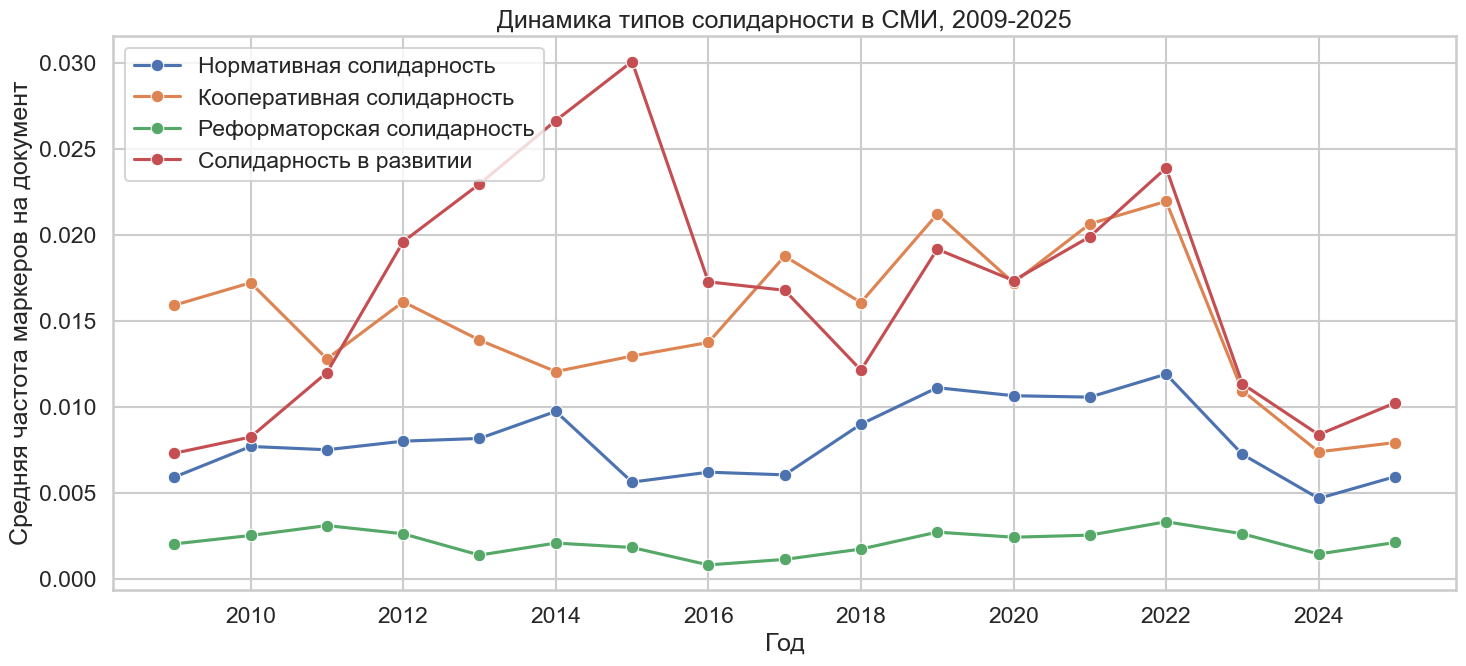

In [30]:
#агрегируем показатели по годам
by_year = (
    df.groupby("year")[["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]].mean().reset_index().sort_values("year"))
plt.figure(figsize=(15, 7))

for col, label in [
    ("norms_freq", "Нормативная солидарность"),
    ("cooperation_freq", "Кооперативная солидарность"),
    ("reform_freq", "Реформаторская солидарность"),
    ("development_freq", "Солидарность в развитии"),
]:
    sns.lineplot(data=by_year, x="year", y=col, marker="o", label=label)

plt.title("Динамика типов солидарности в СМИ, 2009-2025")
plt.xlabel("Год")
plt.ylabel("Средняя частота маркеров на документ")
plt.legend()
plt.tight_layout()
plt.show()

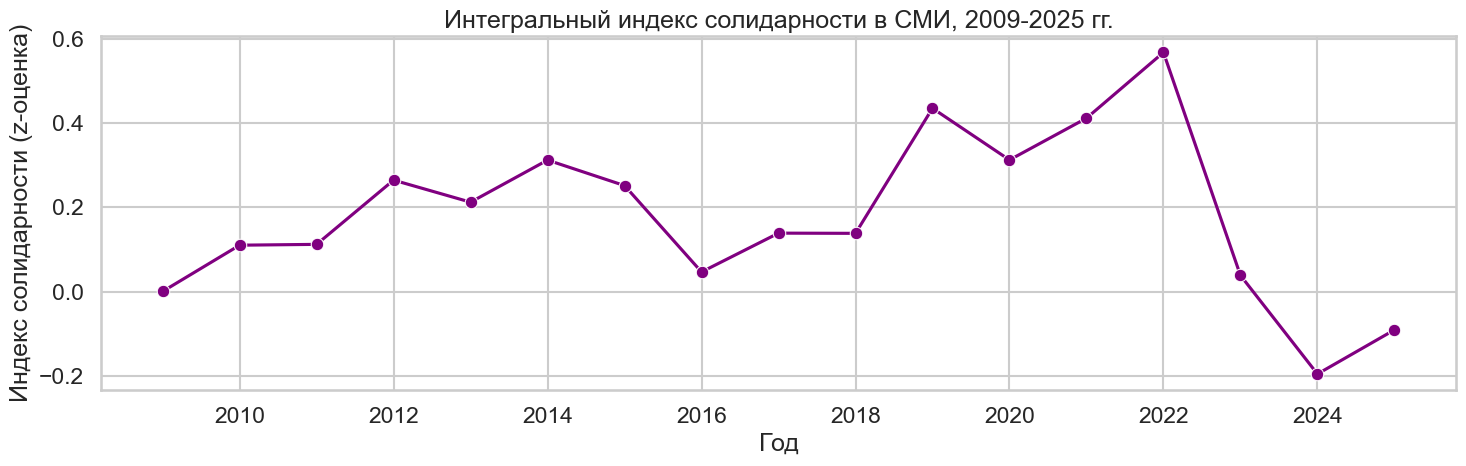

In [33]:
# агрегирование интегрального индекса по годам
by_year_index = (df.groupby("year", as_index=False)["solidarity_index"].mean().sort_values("year"))

plt.figure(figsize=(15, 5))
sns.lineplot(data=by_year_index, x="year", y="solidarity_index", marker="o", color="purple")

plt.title("Интегральный индекс солидарности в СМИ, 2009-2025 гг.")
plt.xlabel("Год")
plt.ylabel("Индекс солидарности (z-оценка)")
plt.tight_layout()
plt.show()

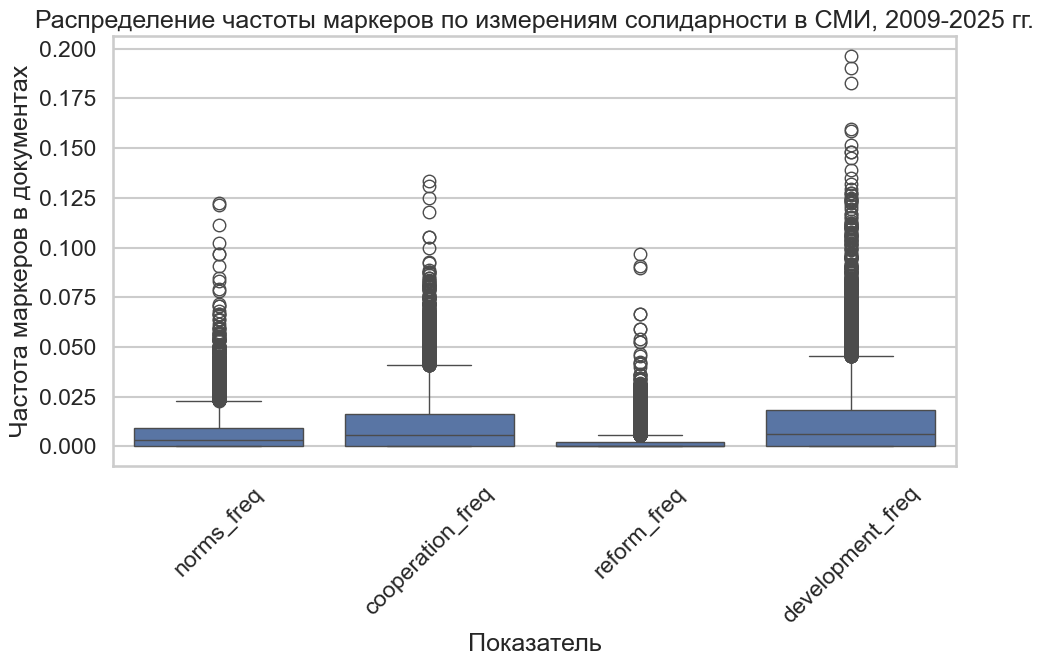

In [35]:
#приводим показатели к «длинному» формату для сравнения распределений
melted = df.melt(
    value_vars=["norms_freq", "cooperation_freq", "reform_freq", "development_freq"],
    var_name="dimension",
    value_name="freq",
)

plt.figure(figsize=(10, 7))
sns.boxplot(data=melted, x="dimension", y="freq")

plt.xticks(rotation=45)
plt.title("Распределение частоты маркеров по измерениям солидарности в СМИ, 2009-2025 гг.")
plt.xlabel("Показатель")
plt.ylabel("Частота маркеров в документах")
plt.tight_layout()
plt.show()

## Что измеряет контекстный блок

Здесь важна не только частота слова `solidarity`, но и то, с кем и в каких сюжетах она связывается.

Логика простая: вокруг маркеров солидарности берется контекстное окно, после чего считаются:
- разнообразие акторов (`partner_diversity`);
- разнообразие тематик (`issue_diversity`).

Если оба показателя растут, риторика становится менее декларативной и более предметной: солидарность привязывается к конкретным коалициям и повесткам.
+     Оценка контекстного разнообразия солидарности в документе:
    - сколько различных акторов оказывается в непосредственном окружении маркеров солидарности;
    - сколько различных тематических областей с ними сочетается

In [37]:
#Лексические маркеры солидарности
#по этим единицам извлекается контекст в тексте
solidarity_markers = {
    "solidarity",
    "cooperation",
    "cooperate",
    "partnership",
    "joint",
    "consensus",
    "collective",
    "mutual",
    "coordination",
    "dialogue",
}

#Акторы для СМИ вокруг БРИКС + ГЮ
solidarity_actors = {
    "brics",
    "global south",
    "brazil",
    "russia",
    "india",
    "china",
    "south africa",
    "iran",
    "egypt",
    "ethiopia",
    "united arab emirates",
    "saudi arabia",
    "united nations",
    "wto",
    "imf",
    "world bank",
    "g20",
    "g7",
}

#тематические области, в рамках которых артикулируется солидарность
solidarity_issues = {
    "trade",
    "investment",
    "finance",
    "debt",
    "climate",
    "adaptation",
    "mitigation",
    "security",
    "sanctions",
    "health",
    "pandemic",
    "education",
    "infrastructure",
    "technology",
    "development",
    "poverty",
    "food security",
    "human rights",
    "energy",
    "multilateralism",
}

#размер контекстного окна: число лемм слева и справа от маркера
context_window = 5

In [39]:
def context_indices(lemmas: list[str], window: int = context_window) -> tuple[int, int]:
    anchor_positions = [i for i, tok in enumerate(lemmas) if tok in solidarity_markers]
    if not anchor_positions:
        return 0, 0

    partners: set[str] = set()
    issues: set[str] = set()

    for pos in anchor_positions:
        left = max(0, pos - window)
        right = min(len(lemmas), pos + window + 1)
        window_tokens = lemmas[left:right]
        window_text = " ".join(window_tokens)

#фиксируем акторов, попадающих в контекст маркеров солидарности
        for actor in solidarity_actors:
            if actor in window_text:
                partners.add(actor)

#фиксируем тематические области, в которых появляется солидарность
        for issue in solidarity_issues:
            if issue in window_text:
                issues.add(issue)

    return len(partners), len(issues)


def compute_context_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    n_partners, n_issues = context_indices(lemmas)
    return pd.Series(
        {
            "partner_diversity": n_partners,
            "issue_diversity": n_issues,
        }
    )

#добавляем контекстные показатели к корпусу
context_df = df.apply(compute_context_row, axis=1)
df = pd.concat([df, context_df], axis=1)

In [42]:
#если несколько раз уже прогон был -df = df.loc[:, ~df.columns.duplicated()]

In [43]:
print(df[["partner_diversity", "issue_diversity"]].describe())
print("Документов с акторным контекстом:", int((df["partner_diversity"] > 0).sum()))
print("Документов с тематическим контекстом:", int((df["issue_diversity"] > 0).sum()))

       partner_diversity  issue_diversity
count       11835.000000     11835.000000
mean            0.715167         0.509168
std             0.981355         1.045191
min             0.000000         0.000000
25%             0.000000         0.000000
50%             0.000000         0.000000
75%             1.000000         1.000000
max             6.000000        12.000000
Документов с акторным контекстом: 5278
Документов с тематическим контекстом: 3299


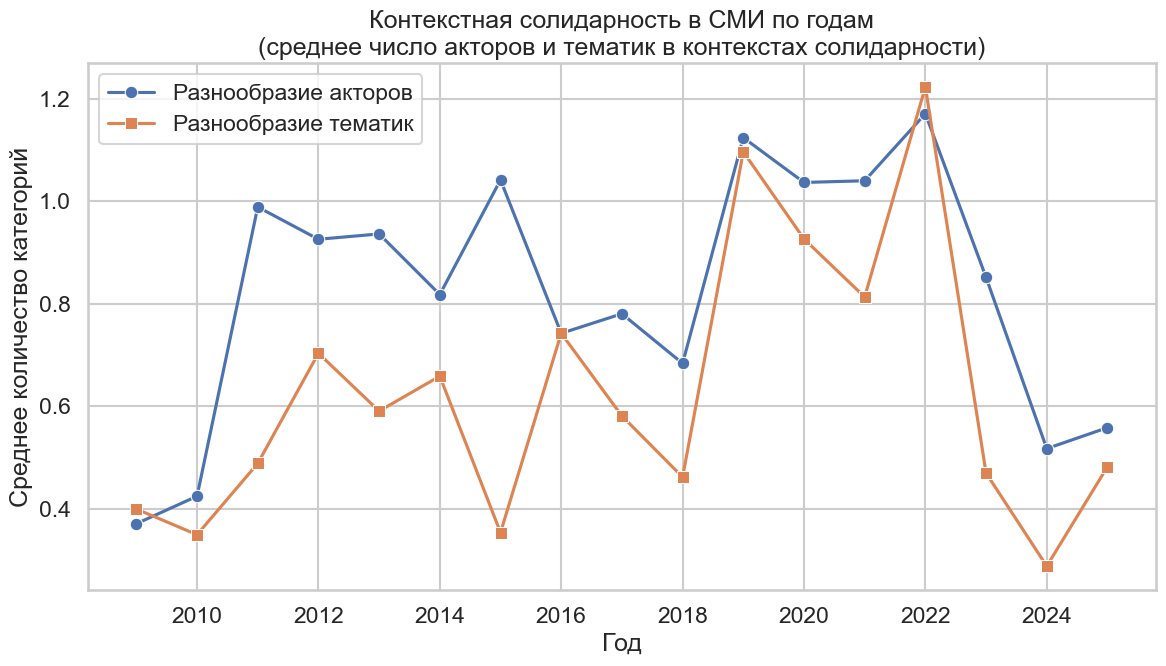

In [45]:
#агрегирование контекстных показателей по годам
context_by_year = (df.groupby("year", as_index=False)[["partner_diversity", "issue_diversity"]].mean().sort_values("year"))

#визуализация динамики контекстной солидарности
plt.figure(figsize=(12, 7))

sns.lineplot(data=context_by_year, x="year", y="partner_diversity", marker="o", label="Разнообразие акторов")

sns.lineplot(data=context_by_year, x="year", y="issue_diversity", marker="s", label="Разнообразие тематик")

plt.title(
    "Контекстная солидарность в СМИ по годам\n"
    "(среднее число акторов и тематик в контекстах солидарности)")
plt.xlabel("Год")
plt.ylabel("Среднее количество категорий")
plt.legend()
plt.tight_layout()
plt.show()

## Сетевой граф

Сетевой граф показывает, какие акторы чаще оказываются в одном солидарном контексте. 
Его сильная сторона — визуализация связей, слабая — чувствительность к настройкам порога

In [47]:
#паттерны акторов
ACTOR_PATTERNS_EN = {
    r'\bglobal south\b': 'Global South',
    r'\bdeveloping countries\b': 'Developing countries',
    r'\bbrics\b': 'BRICS',
    r'\bbrazil\b': 'Brazil',
    r'\brussia\b': 'Russia',
    r'\bindia\b': 'India',
    r'\bchina\b': 'China',
    r'\bsouth africa\b': 'South Africa',
    r'\biran\b': 'Iran',
    r'\begypt\b': 'Egypt',
    r'\bethiopia\b': 'Ethiopia',
    r'\bunited arab emirates\b': 'UAE',
    r'\bsaudi arabia\b': 'Saudi Arabia',
    r'\bunited nations\b': 'UN',
    r'\bwto\b': 'WTO',
    r'\bimf\b': 'IMF',
    r'\bworld bank\b': 'World Bank',
    r'\bg20\b': 'G20',
    r'\bg7\b': 'G7',
}

#маркеры солидарности
SOLIDARITY_ANCHORS_EN = {
    'solidarity', 'cooperation', 'cooperate', 'partnership', 'joint',
    'consensus', 'collective', 'mutual', 'coordination', 'dialogue'
}


def sentence_split(text):
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if s.strip()]


def extract_actors_from_text(text):
    text_low = text.lower()
    actors = set()

    for pattern, name in ACTOR_PATTERNS_EN.items():
        if re.search(pattern, text_low):
            actors.add(name)

    return actors


def has_solidarity_anchor(text):
    text_low = text.lower()
    return any(anchor in text_low for anchor in SOLIDARITY_ANCHORS_EN)


def build_global_south_graph(df_sub):
    G = nx.Graph()

    for _, row in df_sub.iterrows():
        text = row["text_clean"]

        if not isinstance(text, str) or not text.strip():
            continue

        for sent in sentence_split(text):
            if not has_solidarity_anchor(sent):
                continue

            actors = extract_actors_from_text(sent)

#оставляем только предложения, где есть ГЮ
            if "Global South" not in actors:
                continue

#нужна хотя бы одна связь с другим актором
            if len(actors) < 2:
                continue

            for actor in actors:
                if actor == "Global South":
                    continue

                if G.has_edge("Global South", actor):
                    G["Global South"][actor]["weight"] += 1
                else:
                    G.add_edge("Global South", actor, weight=1)

    return G


#граф вокруг ГЮ
G = build_global_south_graph(df)

print("Число узлов:", G.number_of_nodes())
print("Число рёбер:", G.number_of_edges())

#метрики
if G.number_of_nodes() > 0:
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)

    centrality_df = pd.DataFrame({
        "actor": list(G.nodes()),
        "degree_centrality": [degree_centrality.get(a, 0) for a in G.nodes()],
        "betweenness_centrality": [betweenness_centrality.get(a, 0) for a in G.nodes()],
    })

#отдельно покажем силу связи с ГЮ
    centrality_df["edge_weight_with_global_south"] = centrality_df["actor"].map(
        lambda x: G["Global South"][x]["weight"] if x != "Global South" and G.has_edge("Global South", x) else np.nan
    )

    centrality_df = centrality_df.sort_values(
        ["edge_weight_with_global_south", "degree_centrality"],
        ascending=False
    ).reset_index(drop=True)
else:
    centrality_df = pd.DataFrame(
        columns=["actor", "degree_centrality", "betweenness_centrality", "edge_weight_with_global_south"]
    )

print(centrality_df)

Число узлов: 19
Число рёбер: 18
                   actor  degree_centrality  betweenness_centrality  \
0                  BRICS           0.055556                     0.0   
1                  China           0.055556                     0.0   
2                 Brazil           0.055556                     0.0   
3                  India           0.055556                     0.0   
4                 Russia           0.055556                     0.0   
5   Developing countries           0.055556                     0.0   
6           South Africa           0.055556                     0.0   
7                    G20           0.055556                     0.0   
8                   Iran           0.055556                     0.0   
9                  Egypt           0.055556                     0.0   
10              Ethiopia           0.055556                     0.0   
11                    UN           0.055556                     0.0   
12                   UAE           0.055556  

Узлы в визуализированном подграфе: 19
Рёбра с весом не ниже 1 : 18


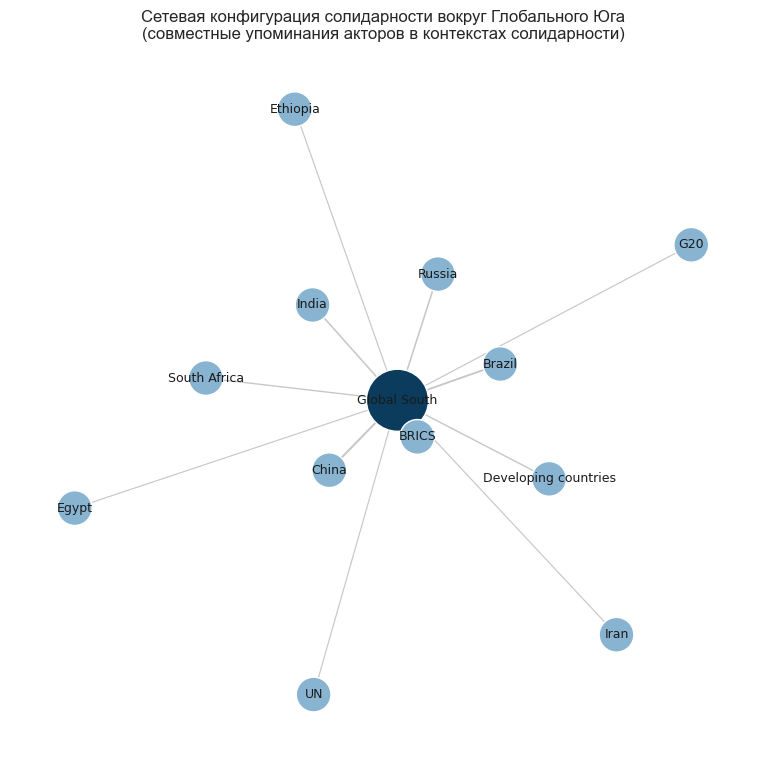

In [64]:
#визуализация сети солидарности вокруг ГЮ
min_weight = 1
max_nodes = 13
center_node = "Global South"

#оставляем только связи с нужным весом
edges_to_keep = [
    (u, v) for u, v, data in G.edges(data=True)
    if data.get("weight", 1) >= min_weight
]
H = G.edge_subgraph(edges_to_keep).copy()

print("Узлы в визуализированном подграфе:", H.number_of_nodes())
print("Рёбра с весом не ниже", min_weight, ":", H.number_of_edges())

#показываем ГЮ и его самых сильных соседей
neighbors = sorted(
    H.neighbors(center_node),
    key=lambda node: H[center_node][node].get("weight", 1),
    reverse=True,
)
selected_nodes = [center_node] + neighbors[:max_nodes - 1]
H = H.subgraph(selected_nodes).copy()

degrees = dict(H.degree())
weights = [H[u][v].get("weight", 1) for u, v in H.edges()]

# Global South ставим в центр.
pos_start = nx.spring_layout(H, k=0.8, seed=42, weight="weight")
pos_start[center_node] = np.array([0.0, 0.0])
pos = nx.spring_layout(
    H,
    pos=pos_start,
    fixed=[center_node],
    k=0.8,
    seed=42,
    weight="weight",
)

#стиль
max_weight = max(weights)
max_degree = max(degrees.values())
edge_widths = [0.8 + 3.2 * (w / max_weight) for w in weights]
node_sizes = [500 + 1500 * (degrees[node] / max_degree) for node in H.nodes()]
node_colors = ["#0b3c5d" if node == center_node else "#88b4d1" for node in H.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(H, pos, width=edge_widths, edge_color="#b0b0b0", alpha=0.7)
nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="white",
    linewidths=1.0,
)
nx.draw_networkx_labels(H, pos, font_size=9, font_family="DejaVu Sans")

plt.title(
    "Сетевая конфигурация солидарности вокруг Глобального Юга\n"
    "(совместные упоминания акторов в контекстах солидарности)",
    fontsize=12,
)
plt.axis("off")
plt.tight_layout()
plt.show()